In [24]:
!pip install opencv-python

     --------------------------------------- 38.2/38.2 MB 10.9 MB/s eta 0:00:00


In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
import os
from glob import glob

In [3]:
os.chdir(r'D:\deep_learning\Sentinel_forestfire\MY_TEST_SENTINEL_IMAGERY_DATA\Google_Earth_Engine\polygons_for_firemasks')

In [4]:
shpfiles = glob('*.shp')

In [5]:
shpfiles

['2022001_2022030.shp', '2022031_2022060.shp', '2022061_2022085.shp']

In [6]:
p_set1 = gpd.read_file(shpfiles[0])

In [7]:
p_set1

,Fire_masks,Fire_IDs,I_date,Sub_ID,ID,geometry
0,1,2022001,2022-01-14,1,1,"MULTIPOLYGON (((456897.860 3947370.249, 456898..."
1,1,2022002,2022-01-12,1,2,"MULTIPOLYGON (((475056.423 4068359.339, 475059..."
2,1,2022003,2022-02-03,1,3,"POLYGON ((386509.718 3876300.458, 386509.718 3..."
3,1,2022004,2022-02-03,1,4,"POLYGON ((464788.919 3906639.409, 464798.501 3..."
4,1,2022005,2022-02-03,1,5,"POLYGON ((531778.451 3913559.057, 531779.113 3..."
5,1,2022006,2022-02-08,1,6,"POLYGON ((445847.240 3848260.071, 445848.703 3..."
6,1,2022007,2022-02-11,1,7,"POLYGON ((468409.312 4046579.172, 468409.639 4..."
7,1,2022008,2022-02-16,1,8,"POLYGON ((338108.279 4210490.384, 338120.979 4..."
8,1,2022009,2022-02-18,1,9,"POLYGON ((470873.957 3974499.571, 470887.186 3..."
9,1,2022010,2022-02-18,1,10,"POLYGON ((541239.428 3956730.145, 541239.165 3..."


In [8]:
p_set1.loc[p_set1["Fire_IDs"]=='2022001']

,Fire_masks,Fire_IDs,I_date,Sub_ID,ID,geometry
0,1,2022001,2022-01-14,1,1,"MULTIPOLYGON (((456897.860 3947370.249, 456898..."


In [20]:
import rasterio
from rasterio.plot import reshape_as_image
import rasterio.mask
from rasterio.features import rasterize

In [21]:
from shapely.geometry import mapping, Point, Polygon
from shapely.ops import cascaded_union

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [27]:
rasters = glob(r'D:\deep_learning\Sentinel_forestfire\MY_TEST_SENTINEL_IMAGERY_DATA\Google_Earth_Engine\temp\*.tif')

In [29]:
with rasterio.open(rasters[0], "r") as src:
    raster_img = src.read()
    raster_meta = src.meta

In [32]:
print("CRS Raster: {}, CRS Vector {}".format(p_set1.crs, src.crs))

CRS Raster: epsg:32652, CRS Vector EPSG:32652


C:\Users\CHAE\AppData\Local\Temp\ipykernel_2164\3073054379.py:27: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for p in row['geometry']:
C:\Users\CHAE\AppData\Local\Temp\ipykernel_2164\3073054379.py:5: ShapelyDeprecationWarning: The 'cascaded_union()' function is deprecated. Use 'unary_union()' instead.
  poly = cascaded_union(polygon)


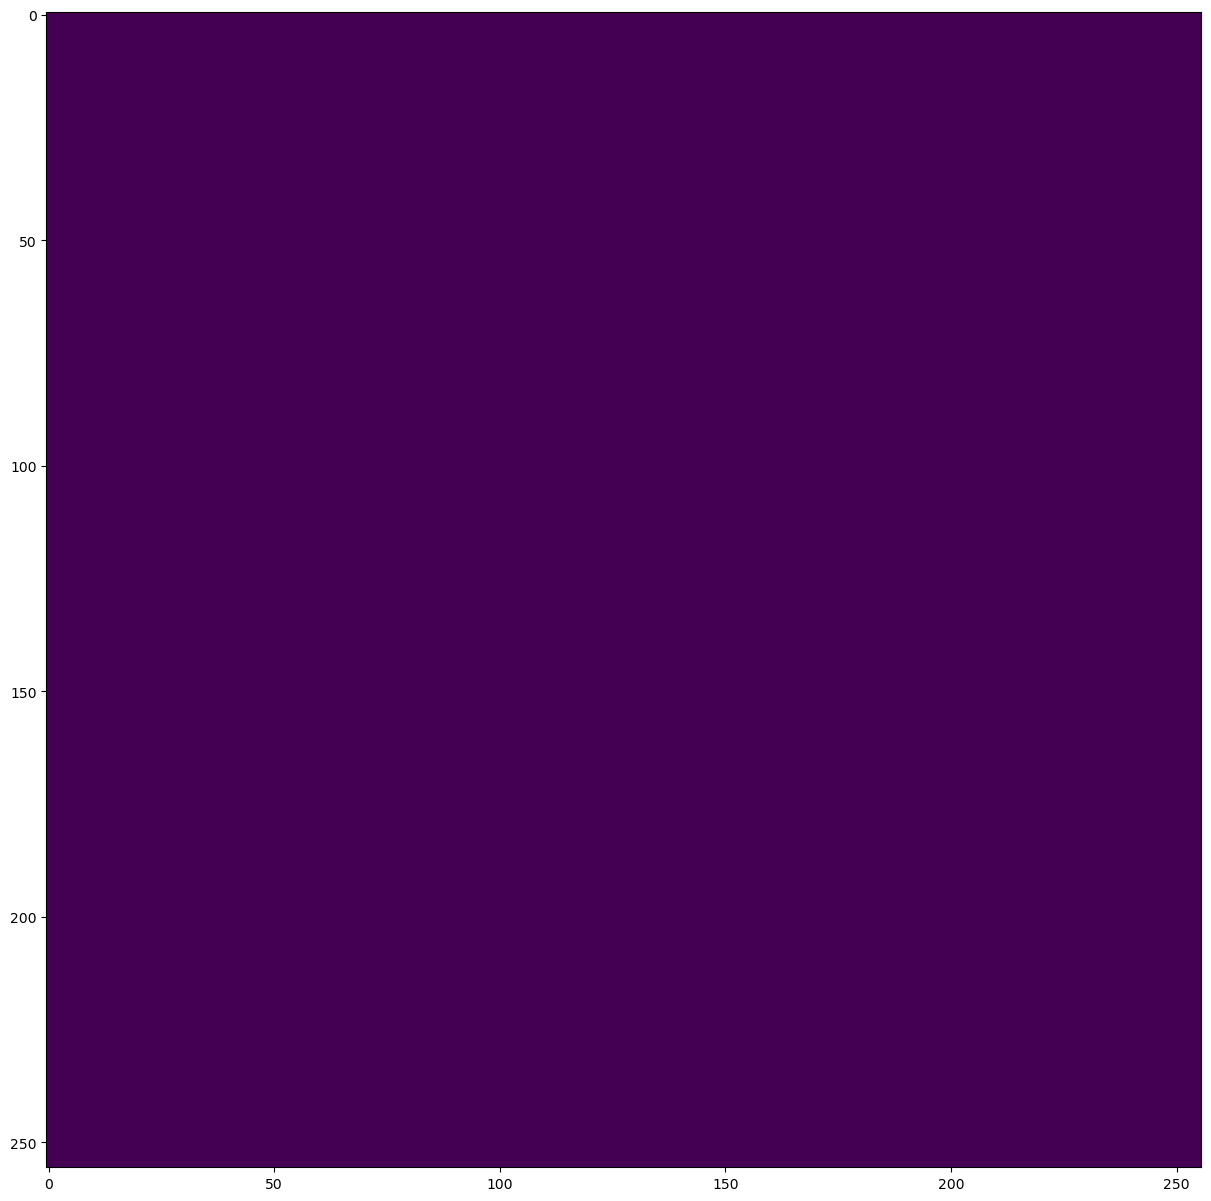

In [39]:
#Generate polygon
def poly_from_utm(polygon, transform):
    poly_pts = []
    
    poly = cascaded_union(polygon)
    for i in np.array(poly.exterior.coords):
        
        # Convert polygons to the image CRS
        poly_pts.append(~transform * tuple(i))
        
    # Generate a polygon object
    new_poly = Polygon(poly_pts)
    return new_poly

# Generate Binary maks

poly_shp = []
im_size = (src.meta['height'], src.meta['width'])
for num, row in p_set1.iterrows():
    if row['geometry'].geom_type == 'Polygon':
        poly = poly_from_utm(row['geometry'], src.meta['transform'])
        poly_shp.append(poly)
    elif row['geometry'].geom_type == 'Multipolygon ':
        poly = poly_from_utm(row['geometry'], src.meta['transform'])
        poly_shp.append(poly)
    else:
        for p in row['geometry']:
            poly = poly_from_utm(p, src.meta['transform'])
            poly_shp.append(poly)

mask = rasterize(shapes=poly_shp,
                 out_shape=im_size)

# Plot the mask

plt.figure(figsize=(15,15))
plt.imshow(mask)

In [40]:
mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)